# **Day 10: Descriptive and Inferential Statistics**
*Module 2 - Probability, Statistics and Optimisation*

Statistics turns data into conclusions. In ML we use it to **summarise** data, quantify **uncertainty** in metrics ("accuracy = 0.87 +/- 0.02"), and decide whether differences are **real or noise**.

> Descriptive statistics summarise data (mean, median, spread). Inferential statistics go further: from a sample we estimate the whole population and say how sure we are, for example with a confidence interval.
>
> *Example:* Measuring 50 field plots gives a mean biomass of 120 Mg/ha. Inference tells us the true forest mean is probably between 110 and 130 Mg/ha.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(10)

## **1. Descriptive Statistics**

| Measure | Formula / function | Robust to outliers? |
|---|---|---|
| Mean | $\bar x=\frac1n\sum x_i$ | No |
| Median | middle value | **Yes** |
| Std deviation | $s=\sqrt{\frac{1}{n-1}\sum(x_i-\bar x)^2}$ | No |
| IQR | $Q_3-Q_1$ | **Yes** |
| MAD | median $\lvert x_i - \text{median}\rvert$ | **Yes** |
| Skewness / kurtosis | asymmetry / tail weight | No |

In [2]:
income = np.r_[rng.lognormal(10, 0.5, 990), rng.lognormal(14, 0.3, 10)]   # a few very rich people
s = pd.Series(income)
print(f"Mean   : {s.mean():>12,.0f}")
print(f"Median : {s.median():>12,.0f}   <- typical value")
print(f"Std    : {s.std():>12,.0f}")
print(f"IQR    : {s.quantile(.75) - s.quantile(.25):>12,.0f}")
print(f"MAD    : {stats.median_abs_deviation(s):>12,.0f}")
print(f"Skew   : {s.skew():.2f} | Kurtosis: {s.kurt():.2f}")

Mean   :       36,892
Median :       21,406   <- typical value
Std    :      139,408
IQR    :       14,783
MAD    :        7,053
Skew   : 12.77 | Kurtosis: 193.71


Ten extreme values pull the mean far above what a typical person earns. **Report the median and IQR for skewed data.**

Why $n-1$? The sample mean is closer to the sample than the true mean is, so dividing by $n$ underestimates the variance (**Bessel's correction**).

In [3]:
true_var = 4.0
biased = [rng.normal(0, 2, 5).var(ddof=0) for _ in range(20000)]
unbiased = [rng.normal(0, 2, 5).var(ddof=1) for _ in range(20000)]
print(f"True variance 4.0 | mean of ddof=0 estimates: {np.mean(biased):.3f} | ddof=1: {np.mean(unbiased):.3f}")

True variance 4.0 | mean of ddof=0 estimates: 3.241 | ddof=1: 4.030


## **2. Sampling Distributions and the Central Limit Theorem**
If we repeated an experiment many times, each sample would give a different mean. The distribution of these means is the **sampling distribution**. The **CLT**: for large $n$, the sample mean is approximately normal with mean $\mu$ and standard deviation $\sigma/\sqrt{n}$, **whatever the original distribution**.

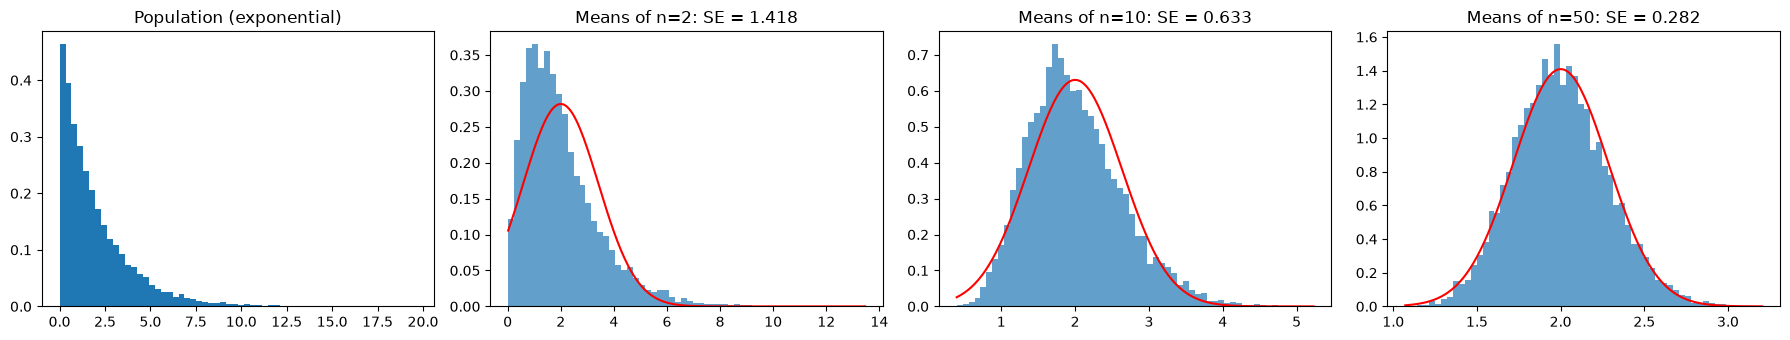

In [4]:
population = rng.exponential(2.0, 1_000_000)   # strongly skewed
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].hist(population[:20000], bins=60, density=True); axes[0].set_title("Population (exponential)")
for ax, n in zip(axes[1:], [2, 10, 50]):
    means = rng.choice(population, (10000, n)).mean(1)
    ax.hist(means, bins=60, density=True, alpha=0.7)
    xs = np.linspace(means.min(), means.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, population.mean(), population.std() / np.sqrt(n)), "r")
    ax.set_title(f"Means of n={n}: SE = {means.std():.3f}")
plt.tight_layout(); plt.show()

## **3. Standard Error and Confidence Intervals**
- **Standard error (SE)** = standard deviation of an estimate: $SE(\bar x) = s/\sqrt n$.
- **95% confidence interval**: $\bar x \pm t_{0.975,\,n-1}\cdot SE$.
- Meaning: if we repeated the study many times, 95% of such intervals would contain the true value.

In [5]:
sample = rng.normal(50, 10, 30)
se = sample.std(ddof=1) / np.sqrt(len(sample))
t_crit = stats.t.ppf(0.975, len(sample) - 1)
print(f"mean = {sample.mean():.2f}, 95% CI = [{sample.mean() - t_crit * se:.2f}, {sample.mean() + t_crit * se:.2f}]")

# Check the coverage claim by simulation
covered = 0
for _ in range(5000):
    smp = rng.normal(50, 10, 30); se_ = smp.std(ddof=1) / np.sqrt(30)
    covered += abs(smp.mean() - 50) <= t_crit * se_
print(f"Coverage of the 95% CI over 5000 repetitions: {covered / 5000:.3f}")

mean = 50.22, 95% CI = [46.00, 54.44]
Coverage of the 95% CI over 5000 repetitions: 0.955


### Confidence interval for a classifier's accuracy
Accuracy is a proportion. With $n$ test samples, $SE = \sqrt{p(1-p)/n}$. The **Wilson interval** behaves better than the normal approximation near 0 or 1.

In [6]:
from statsmodels.stats.proportion import proportion_confint
for n_test in [50, 200, 1000, 10000]:
    correct = int(0.88 * n_test)
    lo, hi = proportion_confint(correct, n_test, method="wilson")
    print(f"accuracy 0.88 on n={n_test:>5}: 95% CI [{lo:.3f}, {hi:.3f}]  width {hi - lo:.3f}")

accuracy 0.88 on n=   50: 95% CI [0.762, 0.944]  width 0.182
accuracy 0.88 on n=  200: 95% CI [0.828, 0.918]  width 0.090
accuracy 0.88 on n= 1000: 95% CI [0.858, 0.899]  width 0.040
accuracy 0.88 on n=10000: 95% CI [0.873, 0.886]  width 0.013


With 50 test samples, "88% accuracy" could be anything from ~76% to ~94%. **Small test sets cannot support strong claims.**

## **4. The Bootstrap**
No formula for the SE of our metric (F1, median, R^2, kappa)? **Resample the test set with replacement** many times and recompute the metric. The spread of the bootstrap values estimates the uncertainty (Efron, 1979).

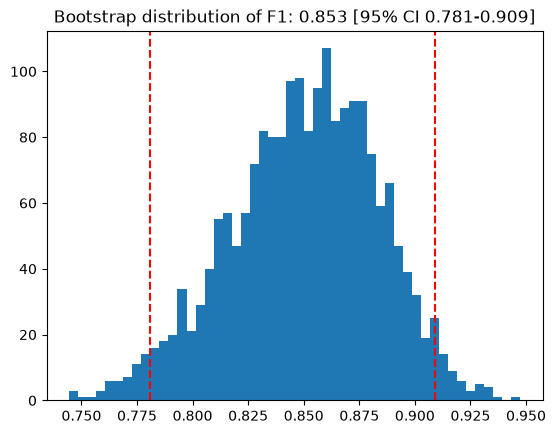

In [7]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X, y = make_classification(n_samples=1200, n_features=10, weights=[0.8], random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
pred = LogisticRegression().fit(X_tr, y_tr).predict(X_te)

def bootstrap_ci(y_true, y_pred, metric, B=2000, alpha=0.05, seed=0):
    r = np.random.default_rng(seed); n = len(y_true)
    vals = np.array([metric(y_true[idx], y_pred[idx]) for idx in r.integers(0, n, (B, n))])
    return metric(y_true, y_pred), np.quantile(vals, [alpha / 2, 1 - alpha / 2]), vals

f1, (lo, hi), boot = bootstrap_ci(y_te, pred, f1_score)
plt.hist(boot, bins=50); plt.axvline(lo, c="r", ls="--"); plt.axvline(hi, c="r", ls="--")
plt.title(f"Bootstrap distribution of F1: {f1:.3f} [95% CI {lo:.3f}-{hi:.3f}]"); plt.show()

## **5. Correlation and Its Pitfalls**

| Coefficient | Measures | Robust? |
|---|---|---|
| Pearson $r$ | **Linear** association | No |
| Spearman $\rho$ | **Monotonic** association (ranks) | Yes |
| Kendall $\tau$ | Concordant pairs | Yes |

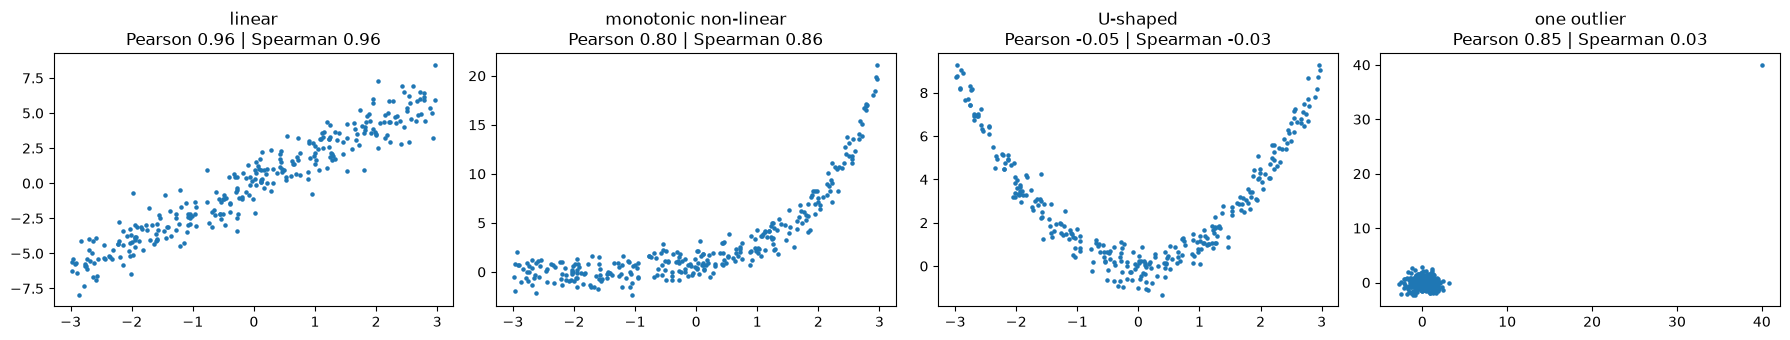

In [8]:
x = rng.uniform(-3, 3, 300)
cases = {"linear": 2 * x + rng.normal(0, 1, 300),
         "monotonic non-linear": np.exp(x) + rng.normal(0, 1, 300),
         "U-shaped": x ** 2 + rng.normal(0, 0.5, 300),
         "one outlier": np.r_[rng.normal(0, 1, 299), 40]}
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, (name, yv) in zip(axes, cases.items()):
    xv = x if name != "one outlier" else np.r_[rng.normal(0, 1, 299), 40]
    ax.scatter(xv, yv, s=5)
    ax.set_title(f"{name}\nPearson {stats.pearsonr(xv, yv)[0]:.2f} | Spearman {stats.spearmanr(xv, yv)[0]:.2f}")
plt.tight_layout(); plt.show()

- The U-shape has **zero correlation** but a strong relationship. Correlation $\neq$ dependence.
- One outlier creates a strong Pearson correlation from nothing.
- And always: **correlation is not causation**.

# **Part 2: Going Deeper - When Samples Are Not Independent**

Standard errors assume **independent** samples. Time series and spatial data (neighbouring pixels!) are **autocorrelated**: each new sample carries less new information. For an AR(1) process with lag-1 autocorrelation $\rho$, the **effective sample size** is approximately

$$n_{\text{eff}} \approx n\frac{1-\rho}{1+\rho}$$

In [9]:
def ar1(n, rho, r):
    e = r.normal(size=n); out = np.empty(n); out[0] = e[0]
    for t in range(1, n):
        out[t] = rho * out[t - 1] + np.sqrt(1 - rho ** 2) * e[t]
    return out

n = 200
for rho in [0.0, 0.5, 0.9]:
    means = [ar1(n, rho, rng).mean() for _ in range(2000)]
    naive_se = 1 / np.sqrt(n)
    print(f"rho={rho}: true SE of mean = {np.std(means):.3f} | naive SE = {naive_se:.3f} | n_eff ~ {n * (1 - rho) / (1 + rho):.0f}")

rho=0.0: true SE of mean = 0.071 | naive SE = 0.071 | n_eff ~ 200
rho=0.5: true SE of mean = 0.122 | naive SE = 0.071 | n_eff ~ 67


rho=0.9: true SE of mean = 0.298 | naive SE = 0.071 | n_eff ~ 11


With $\rho=0.9$, 200 autocorrelated samples carry the information of only ~11 independent ones, and the naive SE is 4x too small. This is why **random train/test splits of neighbouring pixels give over-optimistic accuracy** (Day 88).

## **Practice Problems**
1. Compute the mean, median, std, IQR of `income` after removing the top 1%. What changes most?
2. Bootstrap a 95% CI for the **median** of `sample`.
3. A model has 412 correct predictions out of 500. Report accuracy with a Wilson 95% CI.
4. *(Advanced)* Simulate the coverage of the naive 95% CI for the mean of AR(1) data with rho = 0.7.

In [10]:
# Solution 1
trim = s[s < s.quantile(0.99)]
print(f"mean {trim.mean():,.0f} (was {s.mean():,.0f}), median {trim.median():,.0f} (was {s.median():,.0f})")
# Solution 2
meds = np.median(rng.choice(sample, (5000, len(sample))), axis=1)
print("Median 95% CI:", np.quantile(meds, [0.025, 0.975]).round(2))
# Solution 3
print("Accuracy", 412 / 500, "CI", np.round(proportion_confint(412, 500, method="wilson"), 3))
# Solution 4
cov = np.mean([abs(ar1(200, 0.7, rng).mean()) <= 1.96 / np.sqrt(200) for _ in range(2000)])
print(f"Coverage of naive CI with rho = 0.7: {cov:.2f} (should be 0.95)")

mean 24,003 (was 36,892), median 21,280 (was 21,406)
Median 95% CI: [45.89 55.05]
Accuracy 0.824 CI [0.788 0.855]
Coverage of naive CI with rho = 0.7: 0.58 (should be 0.95)


## **Key References**
- Efron, B. (1979). Bootstrap methods: Another look at the jackknife. *The Annals of Statistics*, 7(1), 1-26.
- Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall.
- Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association*, 22(158), 209-212.
- Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician*, 27(1), 17-21.